# Kelp1 - Cleaning dan Exploratory Data Analysis (EDA)

Notebook ini dibuat untuk memenuhi bagian **3.5 Exploratory Data Analysis (EDA)** dan mendukung aplikasi **Streamlit dataset explorer** untuk Kelompok 1.

Catatan data:
- File anotasi asli berisi 2.745 baris anotasi dari 3 annotator.
- Setelah digabung berdasarkan `_input_hash`, terdapat 915 review unik.
- Metadata `business_name` dan `rating` tidak tersedia pada file anotasi yang diberikan, sehingga kolom tersebut disediakan kosong pada CSV.
- Kategori diisi `Kuliner` berdasarkan isi review yang dominan membahas makanan/tempat makan.


## 1. Import Library dan Konfigurasi Path

In [1]:
from pathlib import Path
import json
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("../dataset")
ANNOTATION_PATH = DATA_DIR / "Kelp1_dataset_anotasi.jsonl"
AGGREGATED_PATH = DATA_DIR / "Kelp1_dataset_anotasi_aggregated.jsonl"
RAW_CSV_PATH = DATA_DIR / "Kelp1_dataset_1.csv"
CLEAN_CSV_PATH = DATA_DIR / "Kelp1_dataset_2.csv"
IRR_NER_PATH = DATA_DIR / "Kelp1_irr_ner.json"
IRR_TEXTCAT_PATH = DATA_DIR / "Kelp1_irr_textcat.json"

LABELS = [
    "PRODUCT_POSITIVE", "PRODUCT_NEGATIVE", "PRODUCT_NEUTRAL",
    "PRICE_POSITIVE", "PRICE_NEGATIVE", "PRICE_NEUTRAL",
    "PLACE_POSITIVE", "PLACE_NEGATIVE", "PLACE_NEUTRAL",
    "PROMOTION_POSITIVE", "PROMOTION_NEGATIVE", "PROMOTION_NEUTRAL",
    "OUT_OF_TOPIC",
]

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.replace("\u200b", "")
    return text

def word_count(text):
    return len(re.findall(r"\b\w+\b", str(text).lower()))

def parse_label(label):
    if label == "OUT_OF_TOPIC":
        return "OUT_OF_TOPIC", "OUT_OF_TOPIC"
    parts = label.rsplit("_", 1)
    return parts[0], parts[1] if len(parts) == 2 else ""


## 2. Load Dataset Anotasi

In [2]:
annotation_rows = load_jsonl(ANNOTATION_PATH)

print("Jumlah baris anotasi:", len(annotation_rows))
print("Jumlah review unik berdasarkan _input_hash:", len({row["_input_hash"] for row in annotation_rows}))
print("Jumlah review unik berdasarkan text:", len({row["text"] for row in annotation_rows}))
print("Jumlah annotator:", len({row.get("_annotator_id", "") for row in annotation_rows}))

pd.DataFrame({
    "annotator_id": list(Counter(row.get("_annotator_id", "") for row in annotation_rows).keys()),
    "jumlah_anotasi": list(Counter(row.get("_annotator_id", "") for row in annotation_rows).values())
})


Jumlah baris anotasi: 2745
Jumlah review unik berdasarkan _input_hash: 915
Jumlah review unik berdasarkan text: 915
Jumlah annotator: 3


,annotator_id,jumlah_anotasi
0,nlp1_genap2526-230712298,915
1,nlp1_genap2526-230712291,915
2,nlp1_genap2526-230712321,915


## 3. Cleaning Sederhana dan Agregasi Anotasi

In [3]:
groups = defaultdict(list)
for row in annotation_rows:
    groups[row["_input_hash"]].append(row)

aggregated = []
for idx, (input_hash, items) in enumerate(groups.items(), start=1):
    text = items[0]["text"]
    label_votes = Counter()
    for item in items:
        for label in set(item.get("accept", [])):
            label_votes[label] += 1

    majority_labels = [label for label in LABELS if label_votes.get(label, 0) >= 2]
    union_labels = [label for label in LABELS if label_votes.get(label, 0) > 0]

    spans_all = []
    for item in items:
        annotator_id = item.get("_annotator_id", "")
        for span in item.get("spans", []):
            start, end = span.get("start"), span.get("end")
            spans_all.append({
                "start": start,
                "end": end,
                "token_start": span.get("token_start"),
                "token_end": span.get("token_end"),
                "label": span.get("label"),
                "entity_text": text[start:end] if isinstance(start, int) and isinstance(end, int) else "",
                "annotator_id": annotator_id,
            })

    cleaned = clean_text(text)
    aggregated.append({
        "review_id": f"Kelp1_{idx:04d}",
        "input_hash": input_hash,
        "category": "Kuliner",
        "business_name": "",
        "rating": "",
        "review_text": text,
        "clean_review_text": cleaned,
        "word_count": word_count(cleaned),
        "token_count": len(items[0].get("tokens", [])),
        "n_annotators": len(items),
        "annotators": sorted({item.get("_annotator_id", "") for item in items}),
        "majority_labels": majority_labels,
        "union_labels": union_labels,
        "label_votes": dict(label_votes),
        "spans_all": spans_all,
        "spans_majority": [span for span in spans_all if span.get("label") in majority_labels],
    })

df_reviews = pd.DataFrame([{
    "review_id": item["review_id"],
    "category": item["category"],
    "business_name": item["business_name"],
    "rating": item["rating"],
    "review_text": item["review_text"],
    "clean_review_text": item["clean_review_text"],
    "word_count": item["word_count"],
    "token_count": item["token_count"],
    "n_annotators": item["n_annotators"],
    "majority_labels": ", ".join(item["majority_labels"]),
    "union_labels": ", ".join(item["union_labels"]),
} for item in aggregated])

df_labels = []
df_entities = []
for item in aggregated:
    for label in LABELS:
        aspect, sentiment = parse_label(label)
        df_labels.append({
            "review_id": item["review_id"],
            "label": label,
            "aspect": aspect,
            "sentiment": sentiment,
            "vote_count": int(item["label_votes"].get(label, 0)),
            "is_majority": label in item["majority_labels"],
            "is_union": label in item["union_labels"],
        })
    for span in item["spans_all"]:
        aspect, sentiment = parse_label(span.get("label", ""))
        df_entities.append({
            "review_id": item["review_id"],
            "annotator_id": span.get("annotator_id", ""),
            "entity_text": span.get("entity_text", ""),
            "label": span.get("label", ""),
            "aspect": aspect,
            "sentiment": sentiment,
            "start": span.get("start"),
            "end": span.get("end"),
            "is_majority_label": span.get("label") in item["majority_labels"],
        })

df_labels = pd.DataFrame(df_labels)
df_entities = pd.DataFrame(df_entities)

print("Review unik:", len(df_reviews))
print("Tabel label:", df_labels.shape)
print("Tabel entitas:", df_entities.shape)
display(df_reviews.head())


Review unik: 915
Tabel label: (11895, 7)
Tabel entitas: (7106, 9)


,review_id,category,business_name,rating,review_text,clean_review_text,word_count,token_count,n_annotators,majority_labels,union_labels
0,Kelp1_0001,Kuliner,,,"Kami kesini malam, jadi tidak panas, sejuk malan krn abis hujan. Sate kambingnya enak, empuk. Gulai empuk dan enak j...","Kami kesini malam, jadi tidak panas, sejuk malan krn abis hujan. Sate kambingnya enak, empuk. Gulai empuk dan enak j...",28,37,3,"PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_POSITIVE","PRODUCT_POSITIVE, PLACE_POSITIVE, PLACE_NEUTRAL, PROMOTION_POSITIVE"
1,Kelp1_0002,Kuliner,,,"Semua menu enak. Pelayanan baik, ramah dan cepat. Tempat bersih dan asri.","Semua menu enak. Pelayanan baik, ramah dan cepat. Tempat bersih dan asri.",12,16,3,"PRODUCT_POSITIVE, PLACE_POSITIVE","PRODUCT_POSITIVE, PLACE_POSITIVE"
2,Kelp1_0003,Kuliner,,,"Muantaaaaap poooool RM yang setia dikunjungi tiap gelaran kustomfest, atau acara acara apapun di JEC tiap ke jogja n...","Muantaaaaap poooool RM yang setia dikunjungi tiap gelaran kustomfest, atau acara acara apapun di JEC tiap ke jogja n...",30,34,3,"PRODUCT_POSITIVE, PROMOTION_POSITIVE","PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_POSITIVE"
3,Kelp1_0004,Kuliner,,,Makanannya saya rekomendasi karena enak dan lezat. Lokasi ada di map.,Makanannya saya rekomendasi karena enak dan lezat. Lokasi ada di map.,11,13,3,PRODUCT_POSITIVE,"PRODUCT_POSITIVE, PROMOTION_POSITIVE, PROMOTION_NEUTRAL"
4,Kelp1_0005,Kuliner,,,my father favourite satay and tengkleng house in Jogjakarta. the important thing it has big parking area,my father favourite satay and tengkleng house in Jogjakarta. the important thing it has big parking area,17,18,3,,"PLACE_POSITIVE, PROMOTION_POSITIVE"


## 4. Simpan Dataset CSV Hasil Rekonstruksi

In [4]:
df_dataset_1 = df_reviews[["review_id", "category", "business_name", "review_text", "rating"]].copy()
df_dataset_2 = df_reviews[["review_id", "category", "business_name", "clean_review_text", "rating", "word_count", "token_count"]].copy()
df_dataset_2 = df_dataset_2.rename(columns={"clean_review_text": "review_text"})
df_dataset_2 = df_dataset_2.drop_duplicates(subset=["review_text"]).reset_index(drop=True)

df_dataset_1.to_csv(RAW_CSV_PATH, index=False, encoding="utf-8-sig")
df_dataset_2.to_csv(CLEAN_CSV_PATH, index=False, encoding="utf-8-sig")

print("Dataset 1 tersimpan:", RAW_CSV_PATH, "| baris:", len(df_dataset_1))
print("Dataset 2 tersimpan:", CLEAN_CSV_PATH, "| baris:", len(df_dataset_2))
display(df_dataset_2.head())


Dataset 1 tersimpan: ../dataset/Kelp1_dataset_1.csv | baris: 915
Dataset 2 tersimpan: ../dataset/Kelp1_dataset_2.csv | baris: 915


,review_id,category,business_name,review_text,rating,word_count,token_count
0,Kelp1_0001,Kuliner,,"Kami kesini malam, jadi tidak panas, sejuk malan krn abis hujan. Sate kambingnya enak, empuk. Gulai empuk dan enak j...",,28,37
1,Kelp1_0002,Kuliner,,"Semua menu enak. Pelayanan baik, ramah dan cepat. Tempat bersih dan asri.",,12,16
2,Kelp1_0003,Kuliner,,"Muantaaaaap poooool RM yang setia dikunjungi tiap gelaran kustomfest, atau acara acara apapun di JEC tiap ke jogja n...",,30,34
3,Kelp1_0004,Kuliner,,Makanannya saya rekomendasi karena enak dan lezat. Lokasi ada di map.,,11,13
4,Kelp1_0005,Kuliner,,my father favourite satay and tengkleng house in Jogjakarta. the important thing it has big parking area,,17,18


## 5. Distribusi Label ABSA

,label,aspect,sentiment,jumlah_review
9,PRODUCT_POSITIVE,PRODUCT,POSITIVE,690
3,PLACE_POSITIVE,PLACE,POSITIVE,358
7,PRODUCT_NEGATIVE,PRODUCT,NEGATIVE,125
8,PRODUCT_NEUTRAL,PRODUCT,NEUTRAL,117
6,PRICE_POSITIVE,PRICE,POSITIVE,110
1,PLACE_NEGATIVE,PLACE,NEGATIVE,79
5,PRICE_NEUTRAL,PRICE,NEUTRAL,53
2,PLACE_NEUTRAL,PLACE,NEUTRAL,42
0,OUT_OF_TOPIC,OUT_OF_TOPIC,OUT_OF_TOPIC,26
4,PRICE_NEGATIVE,PRICE,NEGATIVE,17


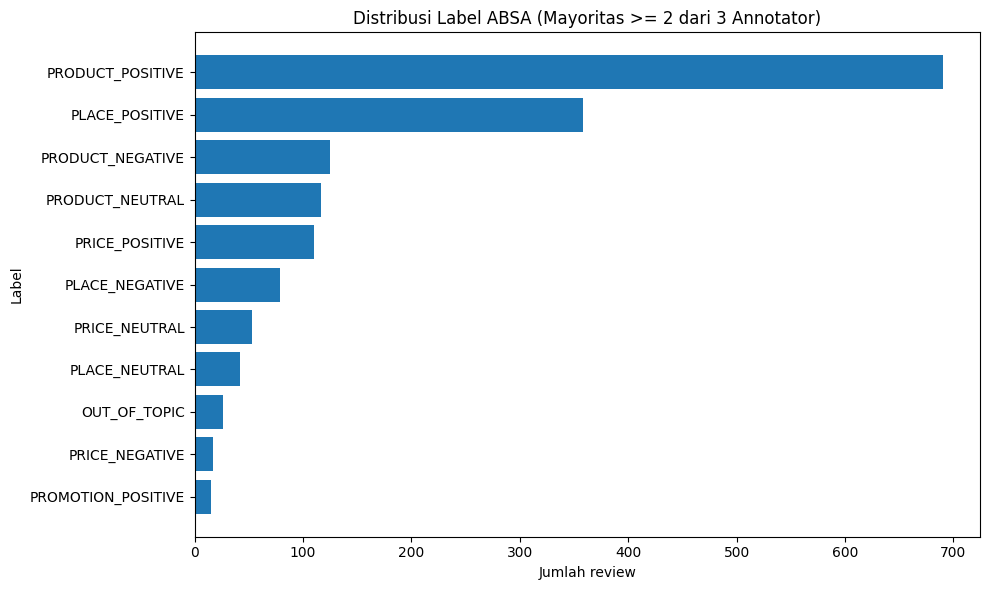

In [5]:
label_distribution = (
    df_labels[df_labels["is_majority"]]
    .groupby(["label", "aspect", "sentiment"])
    .size()
    .reset_index(name="jumlah_review")
    .sort_values("jumlah_review", ascending=False)
)

display(label_distribution)

fig, ax = plt.subplots(figsize=(10, 6))
plot_data = label_distribution.sort_values("jumlah_review")
ax.barh(plot_data["label"], plot_data["jumlah_review"])
ax.set_title("Distribusi Label ABSA (Mayoritas >= 2 dari 3 Annotator)")
ax.set_xlabel("Jumlah review")
ax.set_ylabel("Label")
fig.tight_layout()
plt.show()


## 6. Distribusi Entitas ABSA/NER

,label,aspect,sentiment,jumlah_entitas
9,PRODUCT_POSITIVE,PRODUCT,POSITIVE,2883
3,PLACE_POSITIVE,PLACE,POSITIVE,1454
7,PRODUCT_NEGATIVE,PRODUCT,NEGATIVE,414
8,PRODUCT_NEUTRAL,PRODUCT,NEUTRAL,383
6,PRICE_POSITIVE,PRICE,POSITIVE,284
1,PLACE_NEGATIVE,PLACE,NEGATIVE,267
5,PRICE_NEUTRAL,PRICE,NEUTRAL,130
2,PLACE_NEUTRAL,PLACE,NEUTRAL,105
0,OUT_OF_TOPIC,OUT_OF_TOPIC,OUT_OF_TOPIC,61
4,PRICE_NEGATIVE,PRICE,NEGATIVE,39


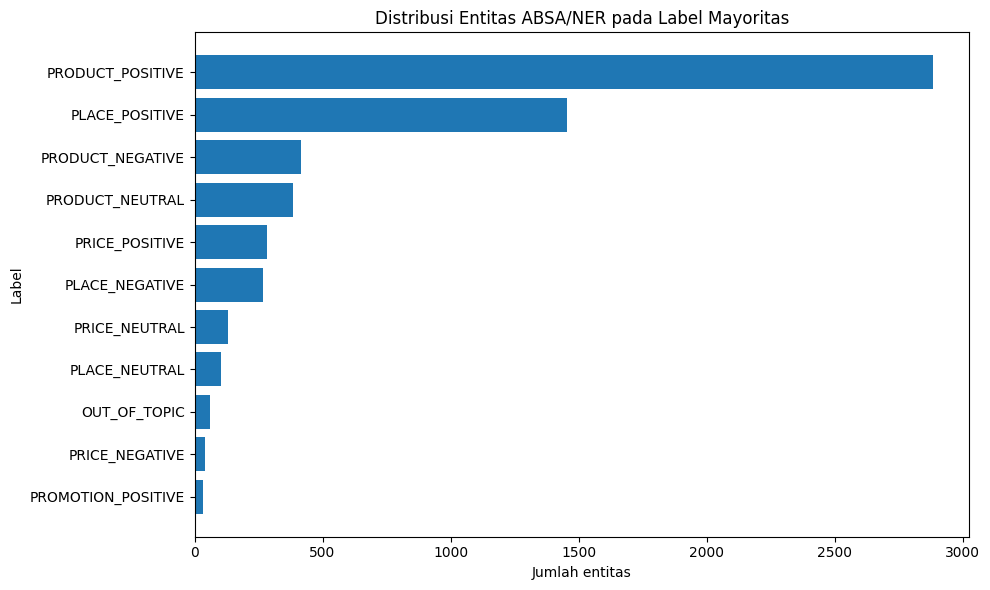

In [6]:
entity_distribution = (
    df_entities[df_entities["is_majority_label"]]
    .groupby(["label", "aspect", "sentiment"])
    .size()
    .reset_index(name="jumlah_entitas")
    .sort_values("jumlah_entitas", ascending=False)
)

display(entity_distribution)

fig, ax = plt.subplots(figsize=(10, 6))
plot_data = entity_distribution.sort_values("jumlah_entitas")
ax.barh(plot_data["label"], plot_data["jumlah_entitas"])
ax.set_title("Distribusi Entitas ABSA/NER pada Label Mayoritas")
ax.set_xlabel("Jumlah entitas")
ax.set_ylabel("Label")
fig.tight_layout()
plt.show()


## 7. Distribusi Panjang Review

,word_count,token_count
count,915.000000,915.000000
mean,21.363934,25.377049
std,24.028835,28.335458
min,6.000000,5.000000
25%,8.000000,10.000000
50%,14.000000,16.000000
75%,24.000000,29.000000
max,286.000000,327.000000


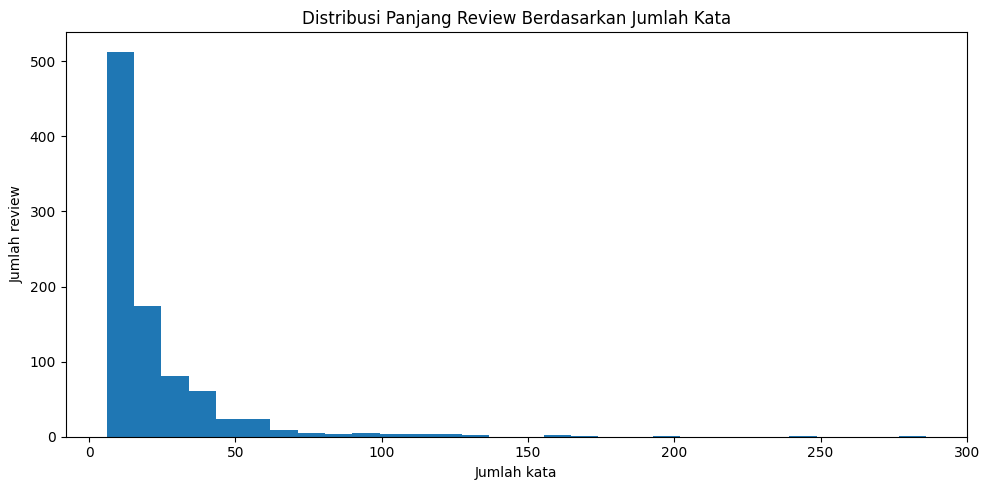

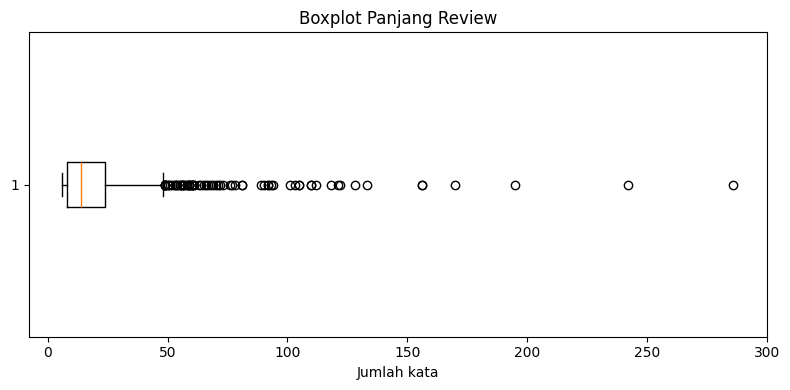

In [7]:
display(df_reviews[["word_count", "token_count"]].describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_reviews["word_count"], bins=30)
ax.set_title("Distribusi Panjang Review Berdasarkan Jumlah Kata")
ax.set_xlabel("Jumlah kata")
ax.set_ylabel("Jumlah review")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(df_reviews["word_count"], vert=False)
ax.set_title("Boxplot Panjang Review")
ax.set_xlabel("Jumlah kata")
fig.tight_layout()
plt.show()


## 8. Distribusi per Aspek dan Sentimen

,aspect,jumlah_review
3,PRODUCT,932
1,PLACE,479
2,PRICE,180
0,OUT_OF_TOPIC,26
4,PROMOTION,15


,sentiment,jumlah_review
3,POSITIVE,1173
0,NEGATIVE,221
1,NEUTRAL,212
2,OUT_OF_TOPIC,26


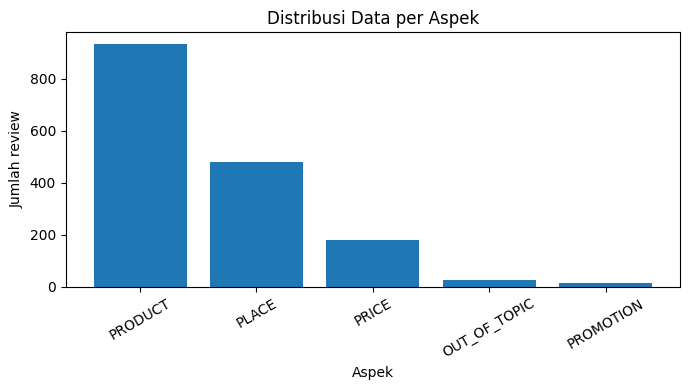

In [8]:
aspect_distribution = (
    df_labels[df_labels["is_majority"]]
    .groupby("aspect")
    .size()
    .reset_index(name="jumlah_review")
    .sort_values("jumlah_review", ascending=False)
)

sentiment_distribution = (
    df_labels[df_labels["is_majority"]]
    .groupby("sentiment")
    .size()
    .reset_index(name="jumlah_review")
    .sort_values("jumlah_review", ascending=False)
)

display(aspect_distribution)
display(sentiment_distribution)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(aspect_distribution["aspect"], aspect_distribution["jumlah_review"])
ax.set_title("Distribusi Data per Aspek")
ax.set_xlabel("Aspek")
ax.set_ylabel("Jumlah review")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


## 9. Matriks Korelasi Antar Label

,PRODUCT_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRICE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PLACE_POSITIVE,PLACE_NEGATIVE,PLACE_NEUTRAL,PROMOTION_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,OUT_OF_TOPIC
PRODUCT_POSITIVE,1.00,-0.13,-0.04,0.16,-0.03,0.11,0.19,-0.07,-0.06,0.01,0.0,0.0,-0.12
PRODUCT_NEGATIVE,-0.13,1.00,0.18,-0.11,0.04,0.02,-0.07,0.04,0.02,0.02,0.0,0.0,-0.07
PRODUCT_NEUTRAL,-0.04,0.18,1.00,-0.03,0.02,0.06,0.04,0.01,0.12,0.00,0.0,0.0,-0.05
PRICE_POSITIVE,0.16,-0.11,-0.03,1.00,-0.05,-0.03,0.14,-0.07,-0.05,0.01,0.0,0.0,-0.00
PRICE_NEGATIVE,-0.03,0.04,0.02,-0.05,1.00,0.00,-0.08,0.04,0.09,0.05,0.0,0.0,-0.02
PRICE_NEUTRAL,0.11,0.02,0.06,-0.03,0.00,1.00,0.11,0.07,0.06,0.00,0.0,0.0,0.04
PLACE_POSITIVE,0.19,-0.07,0.04,0.14,-0.08,0.11,1.00,0.01,0.09,0.02,0.0,0.0,-0.06
PLACE_NEGATIVE,-0.07,0.04,0.01,-0.07,0.04,0.07,0.01,1.00,0.08,0.02,0.0,0.0,-0.03
PLACE_NEUTRAL,-0.06,0.02,0.12,-0.05,0.09,0.06,0.09,0.08,1.00,0.01,0.0,0.0,0.03
PROMOTION_POSITIVE,0.01,0.02,0.00,0.01,0.05,0.00,0.02,0.02,0.01,1.00,0.0,0.0,-0.02


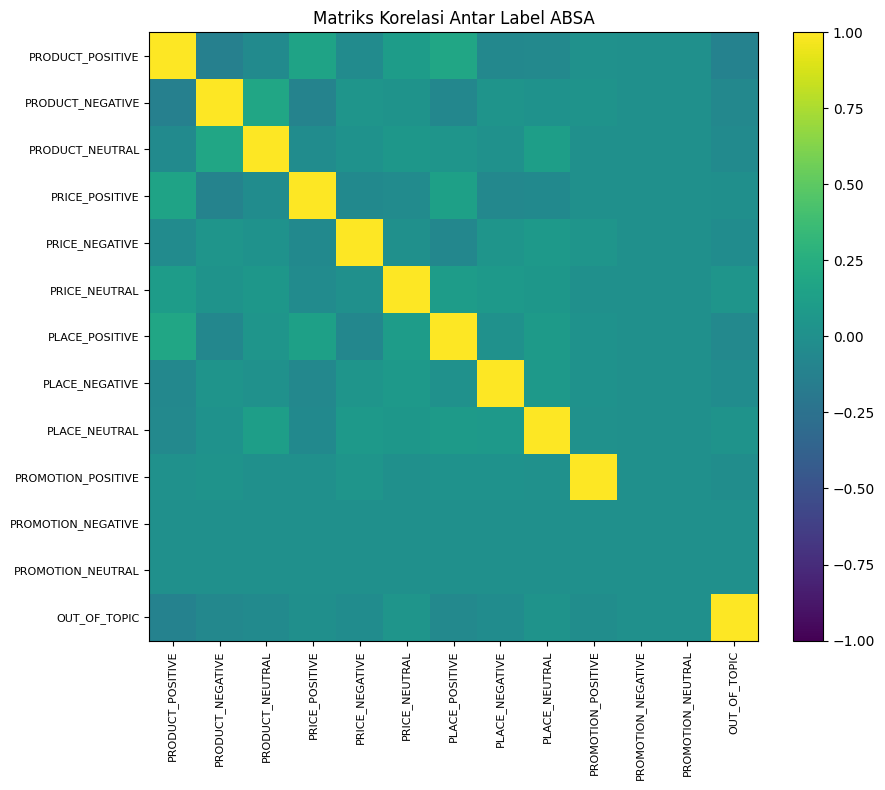

In [9]:
label_matrix = pd.DataFrame(0, index=df_reviews["review_id"], columns=LABELS)

for _, row in df_labels[df_labels["is_majority"]].iterrows():
    label_matrix.loc[row["review_id"], row["label"]] = 1

correlation_matrix = label_matrix.corr().fillna(0)
display(correlation_matrix.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(LABELS)))
ax.set_yticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=90, fontsize=8)
ax.set_yticklabels(LABELS, fontsize=8)
ax.set_title("Matriks Korelasi Antar Label ABSA")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


## 10. Tampilkan IRR

In [10]:
if IRR_TEXTCAT_PATH.exists():
    irr_textcat = json.load(open(IRR_TEXTCAT_PATH, encoding="utf-8"))
    irr_textcat_df = pd.DataFrame.from_dict(irr_textcat, orient="index").reset_index(names="label")
    display(irr_textcat_df[["label", "n_examples", "n_annotators", "percent_agreement", "kripp_alpha", "gwet_ac2"]])
else:
    print("File IRR textcat tidak ditemukan.")

if IRR_NER_PATH.exists():
    irr_ner = json.load(open(IRR_NER_PATH, encoding="utf-8"))
    irr_summary = pd.DataFrame([
        {"metric": key, "value": irr_ner.get(key)}
        for key in ["n_examples", "n_categories", "n_coincident_examples", "n_annotators", "avg_raters_per_example", "pairwise_f1", "pairwise_recall", "pairwise_precision"]
        if key in irr_ner
    ])
    display(irr_summary)
else:
    print("File IRR NER tidak ditemukan.")


,label,n_examples,n_annotators,percent_agreement,kripp_alpha,gwet_ac2
0,PRODUCT_POSITIVE,2544,3,0.820769,0.604483,0.718445
1,PRODUCT_NEGATIVE,2544,3,0.878049,0.687058,0.834315
2,PRODUCT_NEUTRAL,2544,3,0.748707,0.295100,0.632083
3,PRICE_POSITIVE,2544,3,0.876940,0.681305,0.833998
4,PRICE_NEGATIVE,2544,3,0.934959,0.640620,0.928969
5,PRICE_NEUTRAL,2544,3,0.888027,0.456299,0.867772
6,PLACE_POSITIVE,2544,3,0.813378,0.711107,0.636511
7,PLACE_NEGATIVE,2544,3,0.911308,0.759018,0.889027
8,PLACE_NEUTRAL,2544,3,0.849593,0.248683,0.817897
9,PROMOTION_POSITIVE,2544,3,0.777162,-0.035301,0.718719


,metric,value
0,n_examples,2745.00
1,n_categories,13.00
2,n_coincident_examples,915.00
3,n_annotators,3.00
4,avg_raters_per_example,3.00
5,pairwise_f1,0.21
6,pairwise_recall,0.21
7,pairwise_precision,0.23


## Kesimpulan EDA

Berdasarkan data hasil anotasi Kelompok 1:

1. Dataset anotasi berisi 915 review unik dan 2.745 baris anotasi dari 3 annotator.
2. Label yang paling dominan adalah `PRODUCT_POSITIVE`, diikuti `PLACE_POSITIVE`.
3. Panjang review bervariasi, tetapi mayoritas review relatif pendek.
4. Matriks korelasi antar label dapat digunakan untuk melihat kecenderungan kemunculan label bersama, misalnya hubungan antara aspek produk dan tempat.
5. File IRR yang sudah dibuat dosen/kelompok juga dibaca di notebook dan akan ditampilkan di aplikasi Streamlit.
